In [1]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
from scipy.io import loadmat

# read mat file output from Xiaoting Matlab code:
mat = loadmat('fingerprints-from-Xiaoting/Output/fingerprinting-output-Greenland-and-Antarctica.mat')
lon = mat['lon_GL'][0]
lat = mat['lat_GL'].T[0]
ocean_mask= mat['lon_GL']
topo_pres= mat['topo_pres']
Delta_S_Greenland= mat['Delta_S_Greenland']
Ice_mask_Greenland = mat['Ice_mask_Greenland']
Delta_S_Antarctica= mat['Delta_S_Antarctica']
Ice_mask_Antarctica= mat['Ice_mask_Antarctica']

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'
plt.rcParams['font.size'] = 9

print("done.")

done.


In [2]:
# calculate global mean sea level signal:
R=630000 # Earth radius
dlon=(lon[1]-lon[0])*np.pi/180
dlat=(lat[0]-lat[1])*np.pi/180
LON,LAT=np.meshgrid(lon,lat)
GMSL_Greenland=np.nansum(np.cos(LAT*np.pi/180)*Delta_S_Greenland*R**2*dlon*dlat)/(4*np.pi*R**2)
GMSL_Antarctica=np.nansum(np.cos(LAT*np.pi/180)*Delta_S_Antarctica*R**2*dlon*dlat)/(4*np.pi*R**2)
print("GMSL Greenland, Antarctica before normalization=",GMSL_Greenland,GMSL_Antarctica)

# normalize to 1 m GMSL:
Delta_S_Greenland=Delta_S_Greenland/GMSL_Greenland
Delta_S_Antarctica=Delta_S_Antarctica/GMSL_Antarctica

# calculate again after normalization:
GMSL_Greenland=np.nansum(np.cos(LAT*np.pi/180)*Delta_S_Greenland*R**2*dlon*dlat)/(4*np.pi*R**2)
GMSL_Antarctica=np.nansum(np.cos(LAT*np.pi/180)*Delta_S_Antarctica*R**2*dlon*dlat)/(4*np.pi*R**2)
print("GMSL Greenland, Antarctica after=",GMSL_Greenland,GMSL_Antarctica)


GMSL Greenland, Antarctica before normalization= 0.9032215822957252 0.770727263098648
GMSL Greenland, Antarctica after= 1.0 1.0


<Figure size 640x480 with 0 Axes>

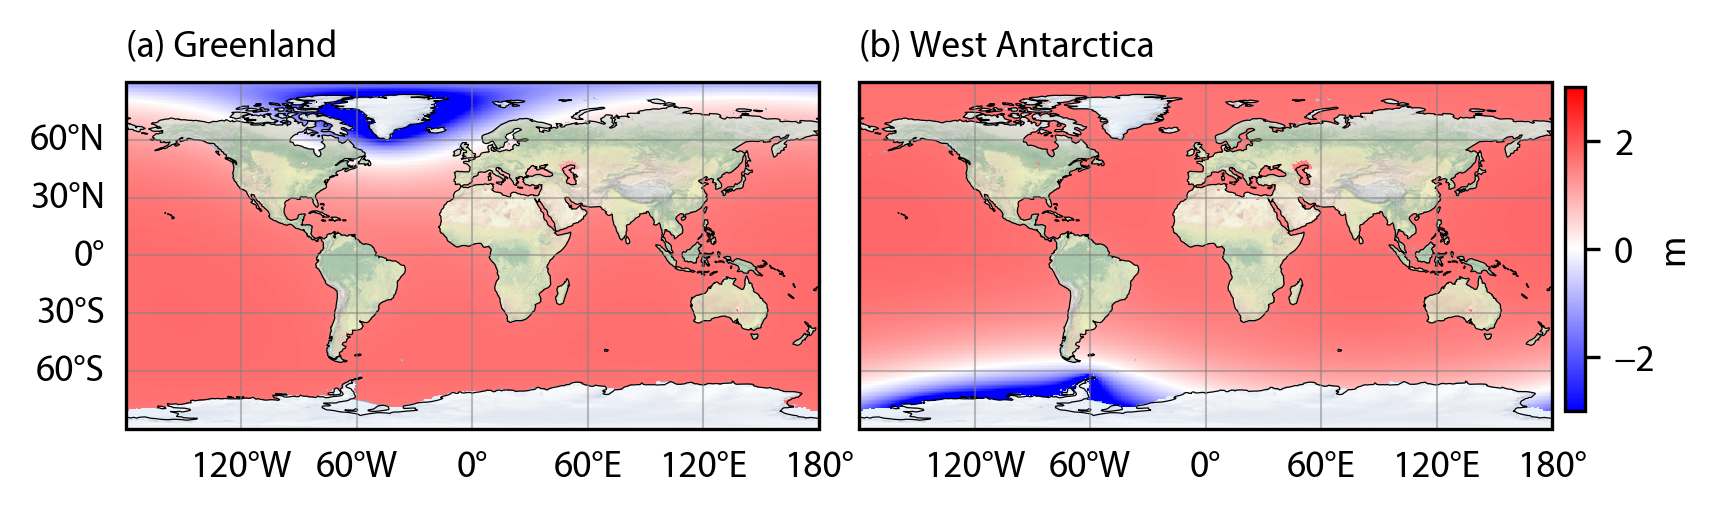

In [3]:
# initialize figure:
plt.clf();
projection=ccrs.PlateCarree(central_longitude=0.0);
fig=plt.figure(figsize=(5.5,1.5),dpi=300);
grid = plt.GridSpec(nrows=1, ncols=2, wspace=-0.2)#, hspace=0.3)
props = dict(boxstyle='round', edgecolor="wheat", facecolor='wheat', alpha=0.9)
# add a column to lon/lat arrays to eliminate white gap at dateline:
# for atmospheric plots:
lon1=1.0*lon[-1]+lon[2]-lon[1]; lon1=np.hstack((lon,lon1))
shrink=0.9

# Greenland:
# ----------
axes=fig.add_subplot(grid[0], projection=ccrs.PlateCarree(0))
axes.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree(0))
axes.coastlines(resolution='110m',lw=0.3)
axes.stock_img()
plt.set_cmap('bwr')
DATA=1.0*Delta_S_Greenland
# add a column to DATA array to eliminate white gap at dateline:
DATA1=1.0*DATA[:,0]; 
DATA1.shape=(len(DATA1[:]),1); DATA1=np.hstack((DATA,DATA1))
c=axes.pcolormesh(lon1,lat, DATA1[:,:],vmin=-3,vmax=3)
#clb=plt.colorbar(c, shrink=shrink, pad=0.02,ax=axes)
#clb.set_label('m')
axes.set_title('(a) Greenland',loc="left",fontsize=9)
gl = axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='-')
gl.xlocator = mticker.FixedLocator([-120, -60, 0, 60, 120, 180])
gl.left_labels = True
gl.right_labels = False
gl.top_labels = False


# Antarctica:
# -----------
axes=fig.add_subplot(grid[1], projection=ccrs.PlateCarree(0))
axes.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
axes.coastlines(resolution='110m',lw=0.3)
axes.stock_img()
plt.set_cmap('bwr')
DATA=1.0*Delta_S_Antarctica
# add a column to DATA array to eliminate white gap at dateline:
DATA1=1.0*DATA[:,0]; 
DATA1.shape=(len(DATA1[:]),1); DATA1=np.hstack((DATA,DATA1))
c=axes.pcolormesh(lon1,lat, DATA1[:,:],vmin=-3,vmax=3)
# clb=plt.colorbar(c, shrink=shrink, pad=0.02)#,ax=axes)
axes.set_title('(b) West Antarctica',loc="left",fontsize=9)
gl = axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='-')
gl.xlocator = mticker.FixedLocator([-120, -60, 0, 60, 120, 180])
gl.left_labels = False
gl.right_labels = False
gl.top_labels = False

fig.subplots_adjust(left=0.0,right=1.0)
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.72])
clb=fig.colorbar(c, cax=cbar_ax)
clb.set_label('m',labelpad=0)


fig.savefig("Output/sea-level-fingerprint-Greenland-and-Antarctica.pdf",bbox_inches='tight')